Imports

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
import torch
import numpy as np
from sentence_transformers import SentenceTransformer
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix

Carga de datos

In [2]:
data = pd.read_csv("../../datasets/cleaned_data.csv", names=["text", "sentiment"], skiprows=1)
print(data.head())
print("----------------------------------------------------------------------")
print(data.info())

                                                text  sentiment
0  geosolutions technology leverage benefon gps s...          1
1                       esi lows bk real possibility         -1
2  last quarter componenta net sales doubled eurm...          1
3  according <ORG> major construction companies f...          0
4  swedish buyout firm sold remaining percent sta...          0
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       5841 non-null   object
 1   sentiment  5842 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 91.4+ KB
None


Balanceo

In [3]:
neutral = data[data['sentiment'] == 0]
positive = data[data['sentiment'] == 1]
negative = data[data['sentiment'] == -1]
total = len(data)

print(f"Neutral: {len(neutral)} ({len(neutral) / total * 100:.2f}%)")
print(f"Positive: {len(positive)} ({len(positive) / total * 100:.2f}%)")
print(f"Negative: {len(negative)} ({len(negative) / total * 100:.2f}%)")

Neutral: 3130 (53.58%)
Positive: 1852 (31.70%)
Negative: 860 (14.72%)


División de datos

In [4]:
data_train_val, data_test = train_test_split(data,
                                            test_size=0.15,
                                            stratify=data['sentiment'],
                                            random_state=505)

data_train, data_val = train_test_split(
    data_train_val,
    test_size = 0.176,
    stratify=data_train_val['sentiment'],
    random_state=505
)

print("Tamaños:")
print(f"  Train:      {len(data_train)}")
print(f"  Validation: {len(data_val)}")
print(f"  Test:       {len(data_test)}")

Tamaños:
  Train:      4091
  Validation: 874
  Test:       877


Distribución de clases

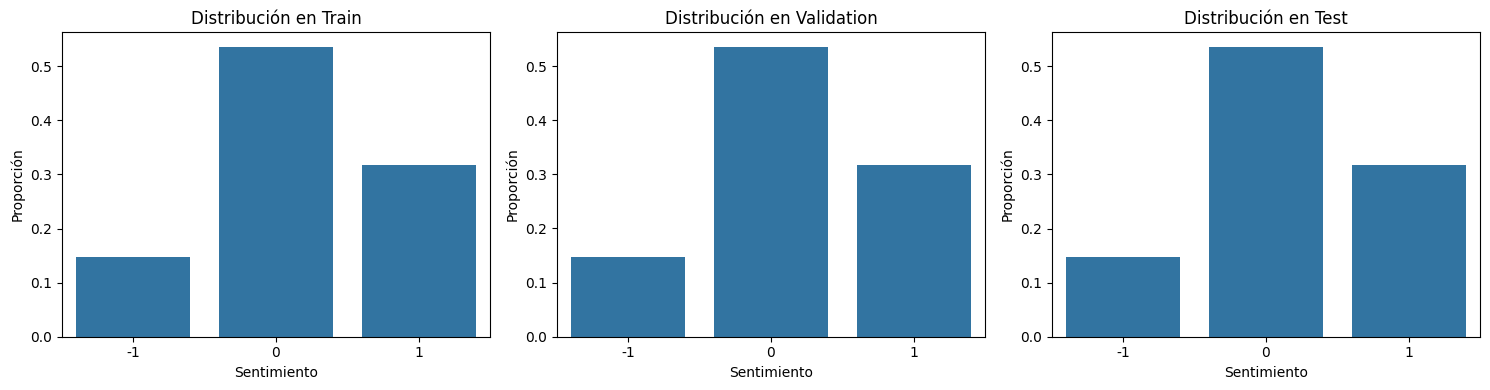

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_class_dist(df, title, ax):
    dist = df["sentiment"].value_counts(normalize=True).sort_index()
    sns.barplot(x=dist.index, y=dist.values, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Sentimiento")
    ax.set_ylabel("Proporción")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_class_dist(data_train, "Distribución en Train", axes[0])
plot_class_dist(data_val,   "Distribución en Validation", axes[1])
plot_class_dist(data_test,  "Distribución en Test", axes[2])
plt.tight_layout()
plt.show()


Tratamiento del desbalanceo de clases

In [6]:
label_map = {-1: 0, 0: 1, +1: 2}
y_train = data_train["sentiment"].map(label_map).values

In [7]:
classes = np.array([0, 1, 2])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
    )

class_weights = torch.tensor(weights, dtype=torch.float)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Pesos de clase (neg, neu, pos):", weights)

Pesos de clase (neg, neu, pos): [2.26522702 0.62211071 1.05140067]


In [10]:
model_name = "philschmid/bge-base-financial-matryoshka"
embedder = SentenceTransformer(model_name)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\macroymercados\company-sentiment\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\macroymercados\.cache\huggingface\hub\models--philschmid--bge-base-financial-matryoshka. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/202 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Generación de embeddings

In [11]:
train_texts = data_train["text"].tolist()
val_texts = data_val["text"].tolist()
test_texts = data_test["text"].tolist()

In [12]:
print("Codificando train...")
train_emb = embedder.encode(train_texts, batch_size=32, show_progress_bar=True)
print("Codificando val...")
val_emb   = embedder.encode(val_texts,   batch_size=32, show_progress_bar=True)
print("Codificando test...")
test_emb  = embedder.encode(test_texts,  batch_size=32, show_progress_bar=True)

Codificando train...


Batches:   0%|          | 0/128 [00:00<?, ?it/s]

Codificando val...


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Codificando test...


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

Mapeo etiquetas para torch y dataloaders

In [13]:
label_map = {-1:0, 0:1, +1:2}
y_train   = torch.tensor(data_train["sentiment"].map(label_map).values)
y_val     = torch.tensor(data_val["sentiment"].map(label_map).values)
y_test    = torch.tensor(data_test["sentiment"].map(label_map).values)

In [14]:
X_train = torch.tensor(train_emb, dtype=torch.float)
X_val   = torch.tensor(val_emb,   dtype=torch.float)
X_test  = torch.tensor(test_emb,  dtype=torch.float)

In [17]:
batch_size = 32
train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

In [18]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size)
test_loader  = DataLoader(test_ds,  batch_size=batch_size)

In [19]:
class Classifier(nn.Module):
    def __init__(self, emb_dim=768, hidden_dim=256, n_classes=3, dropout=0.2):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(emb_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes)
        )
    def forward(self, x):
        return self.fc(x)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = Classifier().to(device)

In [21]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [22]:
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-2)

In [23]:
total_steps = len(train_loader) * 5  # p.ej. 5 epochs
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

Entrenamiento y validación

In [24]:
def train_epoch():
    model.train()
    total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def eval_epoch(loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss   = criterion(logits, y)
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

In [ ]:
best_val_loss = float("inf")
for epoch in range(1, 100):  # 5 epochs
    train_loss = train_epoch()
    val_loss, val_acc = eval_epoch(val_loader)
    print(f"Epoch {epoch} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        print("Modelo guardado.")

# 8. Carga y evaluación final en test
model.load_state_dict(torch.load("best_model.pt"))
test_loss, test_acc = eval_epoch(test_loader)
print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

Epoch 1 | Train loss: 1.0779 | Val loss: 1.0798 | Val acc: 0.5538
  ? Modelo guardado.
Epoch 2 | Train loss: 1.0778 | Val loss: 1.0798 | Val acc: 0.5538
Epoch 3 | Train loss: 1.0778 | Val loss: 1.0798 | Val acc: 0.5538
Epoch 4 | Train loss: 1.0779 | Val loss: 1.0798 | Val acc: 0.5538
Epoch 5 | Train loss: 1.0779 | Val loss: 1.0798 | Val acc: 0.5538
Epoch 6 | Train loss: 1.0776 | Val loss: 1.0798 | Val acc: 0.5538
Epoch 7 | Train loss: 1.0778 | Val loss: 1.0798 | Val acc: 0.5538
Epoch 8 | Train loss: 1.0778 | Val loss: 1.0798 | Val acc: 0.5538
Epoch 9 | Train loss: 1.0780 | Val loss: 1.0798 | Val acc: 0.5538
Epoch 10 | Train loss: 1.0778 | Val loss: 1.0798 | Val acc: 0.5538
Epoch 11 | Train loss: 1.0779 | Val loss: 1.0798 | Val acc: 0.5538
Epoch 12 | Train loss: 1.0779 | Val loss: 1.0798 | Val acc: 0.5538
Epoch 13 | Train loss: 1.0778 | Val loss: 1.0798 | Val acc: 0.5538
Epoch 14 | Train loss: 1.0779 | Val loss: 1.0798 | Val acc: 0.5538
Epoch 15 | Train loss: 1.0779 | Val loss: 1.0798 |

In [28]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        preds  = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y.cpu().numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

# 2) Classification report
print(classification_report(
    y_true, y_pred,
    target_names=["negativo","neutral","positivo"],
    digits=4
))

# 3) Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
print("Matriz de confusión:\n", cm)

              precision    recall  f1-score   support

    negativo     0.3669    0.7054    0.4828       129
     neutral     0.6329    0.8106    0.7108       470
    positivo     0.9630    0.0935    0.1705       278

    accuracy                         0.5678       877
   macro avg     0.6543    0.5365    0.4547       877
weighted avg     0.6984    0.5678    0.5060       877

Matriz de confusión:
 [[ 91  38   0]
 [ 88 381   1]
 [ 69 183  26]]
